# Credit Card Fraud Detection
### Kaggle Dataset — End-to-End ML Pipeline

This notebook covers the full pipeline for fraud detection: loading the data, some EDA to understand what we're working with, preprocessing, and then training three different classifiers to compare their performance.

**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Features:** 28 PCA-transformed components (V1–V28) + Time, Amount, Class  
**Target:** `Class` — 0 for Normal, 1 for Fraud

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive,files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


## Loading the Dataset

Reading in the CSV file. The dataset has ~284K transactions. Most columns (V1–V28) are already PCA-transformed so we don't see the raw features — only `Time`, `Amount`, and `Class` are in their original form.

In [ ]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Shape & Info

Quick look at dimensions, column types, and memory usage.

In [ ]:
print('Shape:', df.shape)
print()
df.info()

Shape: (284807, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

### Duplicate Check

Checking if the dataset has any duplicate rows — important to verify before modelling.

In [ ]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')
if dup_count > 0:
    print(f'Percentage: {dup_count / len(df) * 100:.2f}%')
    df.drop_duplicates(inplace=True)
    print(f'After removing duplicates: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 1081
Percentage: 0.38%
After removing duplicates: (283726, 31)


## Exploratory Data Analysis (EDA)

Let's get a feel for the data before touching any models.

In [ ]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### Class Distribution

Checking unique class values and counts. We already know this is going to be very imbalanced — just confirming by how much.

In [ ]:
df['Class'].unique()

array([0, 1])

In [ ]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


In [ ]:
counts = df['Class'].value_counts()

percentage = df['Class'].value_counts(normalize=True)*100


summary_Table = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentage.map('{:.2f}%'.format)
})
summary_Table
summary_Table.index = ['Normal (0)', 'Fraud (1)']


summary_Table


,Count,Percentage (%)
Normal (0),283253,99.83%
Fraud (1),473,0.17%


### Visualizing the Imbalance

Using log scale on the y-axis because the gap between Normal and Fraud is so large that a regular bar chart makes the fraud bar nearly invisible.

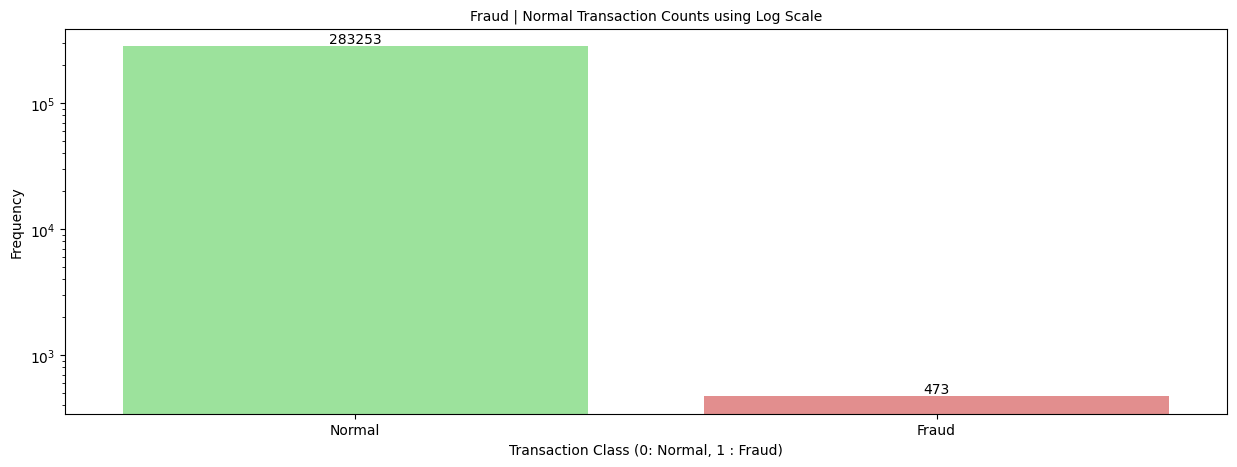

In [ ]:
colors = ['lightgreen','lightcoral']
plt.figure(figsize=(15,5))
sns.barplot(x=counts.index,y=counts.values,palette=colors)
plt.yscale('log')
plt.title(('Fraud | Normal Transaction Counts using Log Scale'),fontsize=10)
plt.xlabel('Transaction Class (0: Normal, 1 : Fraud)')
plt.ylabel('Frequency')
plt.xticks(ticks=[0, 1], labels=['Normal', 'Fraud'])
for i, count in enumerate(counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom',fontsize=10)

plt.show()




### Class Imbalance in the Dataset
The dataset is highly imbalanced. Around 99.83% of the transactions are normal (284,315), while only 0.17% are fraudulent (492). This shows that fraudulent transactions are extremely rare compared to normal ones. Because of this imbalance, a machine learning model could achieve very high accuracy simply by predicting most transactions as normal. However, that would fail to detect actual fraud cases. Therefore, in fraud detection problems, it is important to use evaluation metrics such as precision, recall, and F1-score instead of relying only on accuracy.

### Transaction Amount Distribution — Normal vs Fraud

Comparing how transaction amounts are distributed across both classes. Fraud transactions tend to cluster at lower amounts, but there are some high-value outliers too.

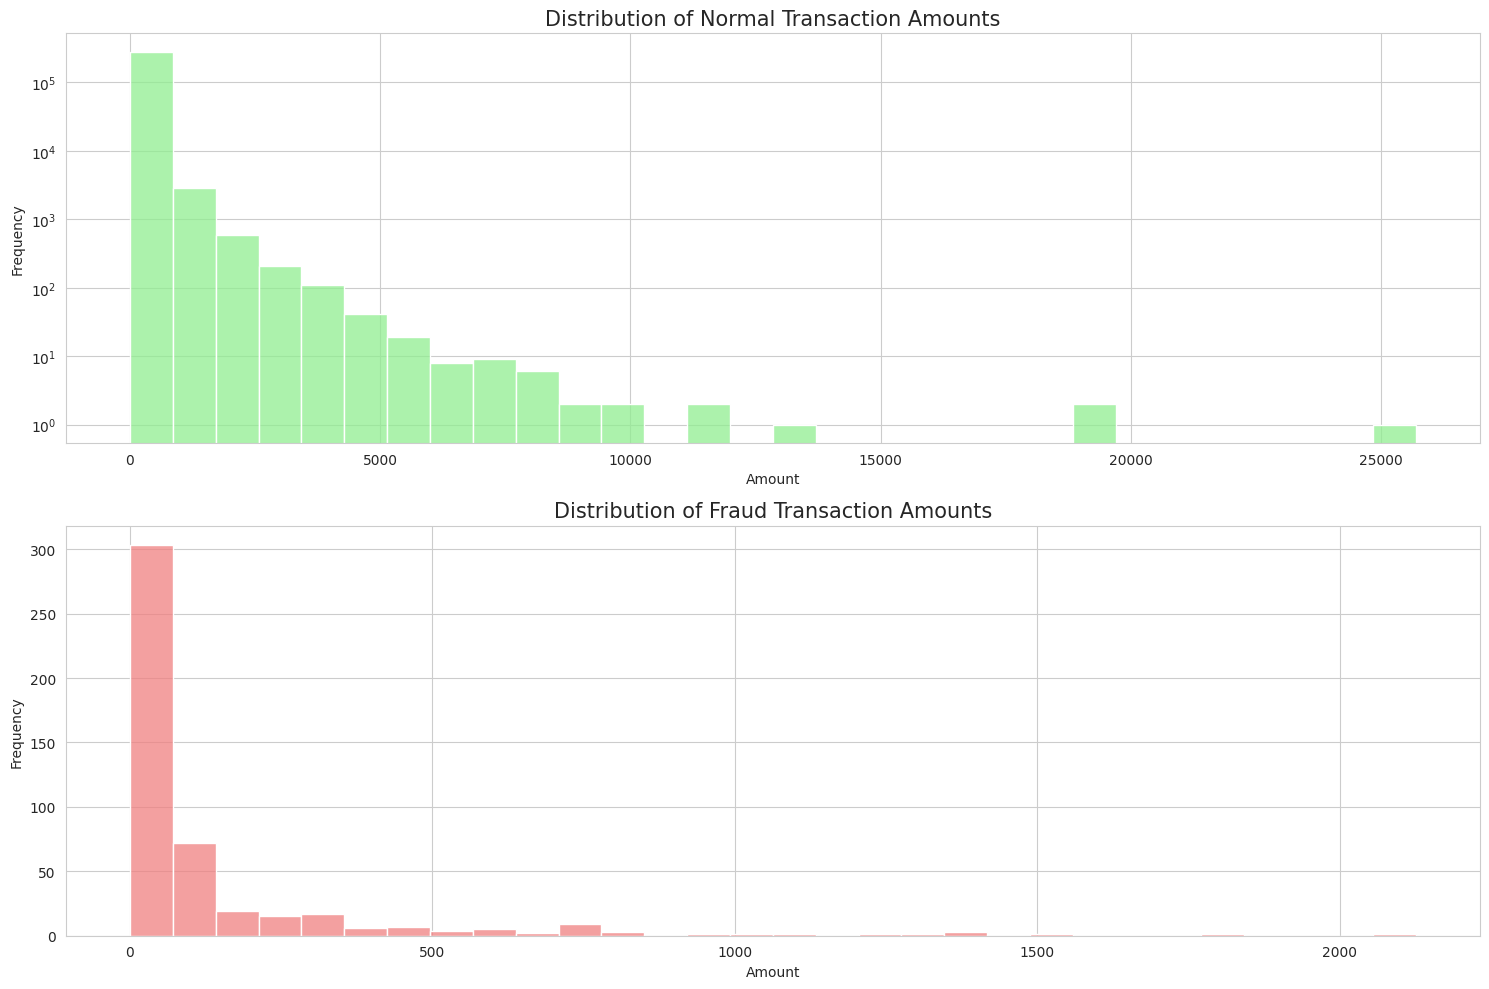

In [ ]:
sns.set_style('whitegrid')
fig, (ax1 ,ax2) = plt.subplots(2,1,figsize=(15,10))

# Creating Histogram for Normal Transaction

sns.histplot(df[df['Class']==0]["Amount"],bins=30, ax= ax1,color='lightgreen')
ax1.set_title("Distribution of Normal Transaction Amounts",fontsize=15)
ax1.set_yscale('log')
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Amount')



# Creating Histogram for Fraud Transaction
sns.histplot(df[df['Class']==1]["Amount"],bins=30 ,ax = ax2 ,color='lightcoral')
ax2.set_title("Distribution of Fraud Transaction Amounts",fontsize=15)
ax2.set_ylabel('Frequency')
ax2.set_xlabel('Amount')
plt.tight_layout()
plt.show()


### Amount Boxplot — Normal vs Fraud

Boxplot comparison to see the spread and outliers in transaction amounts for each class.

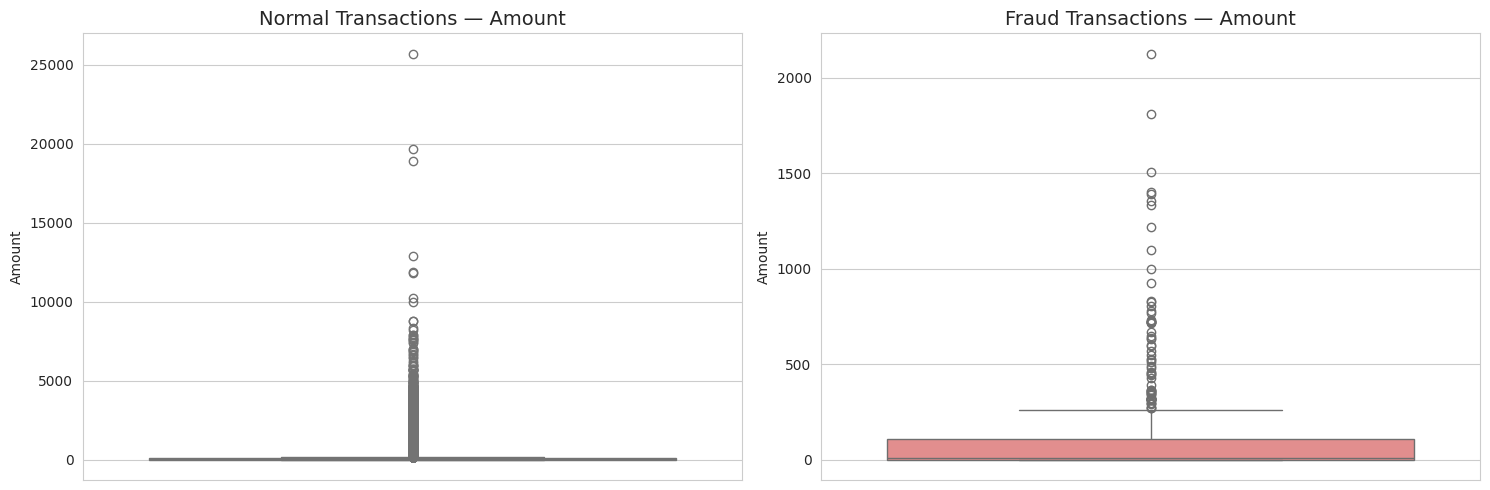

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(y=df[df['Class']==0]['Amount'], ax=ax1, color='lightgreen')
ax1.set_title('Normal Transactions — Amount', fontsize=14)
ax1.set_ylabel('Amount')

sns.boxplot(y=df[df['Class']==1]['Amount'], ax=ax2, color='lightcoral')
ax2.set_title('Fraud Transactions — Amount', fontsize=14)
ax2.set_ylabel('Amount')

plt.tight_layout()
plt.show()

In [ ]:
df_fraud    = df[df['Class']==1].copy()
df_no_fraud = df[df['Class']==0].copy()

print('Fraud_Describe is : ', df_fraud.describe())
print('No_Fraud_Describe is : ', df_no_fraud.describe())

Fraud_Describe is :                  Time          V1          V2          V3          V4  \
count     473.000000  473.000000  473.000000  473.000000  473.000000   
mean    80450.513742   -4.498280    3.405965   -6.729599    4.472591   
std     48636.179973    6.593145    4.122500    6.909647    2.871523   
min       406.000000  -30.552380   -8.402154  -31.103685   -1.313275   
25%     41203.000000   -5.603690    1.145381   -7.926507    2.288644   
50%     73408.000000   -2.271755    2.617105   -4.875397    4.100098   
75%    129095.000000   -0.361428    4.571743   -2.171454    6.290918   
max    170348.000000    2.132386   22.057729    2.250210   12.114672   

               V5          V6          V7          V8          V9  ...  \
count  473.000000  473.000000  473.000000  473.000000  473.000000  ...   
mean    -2.957197   -1.432518   -5.175912    0.953255   -2.522124  ...   
std      5.278831    1.715347    6.858024    5.585950    2.465047  ...   
min    -22.105532   -6.406267  -43

### Time vs Amount — Scatter Plot

Plotting each transaction against time and amount to see if fraud cases cluster at specific time windows or amount ranges.

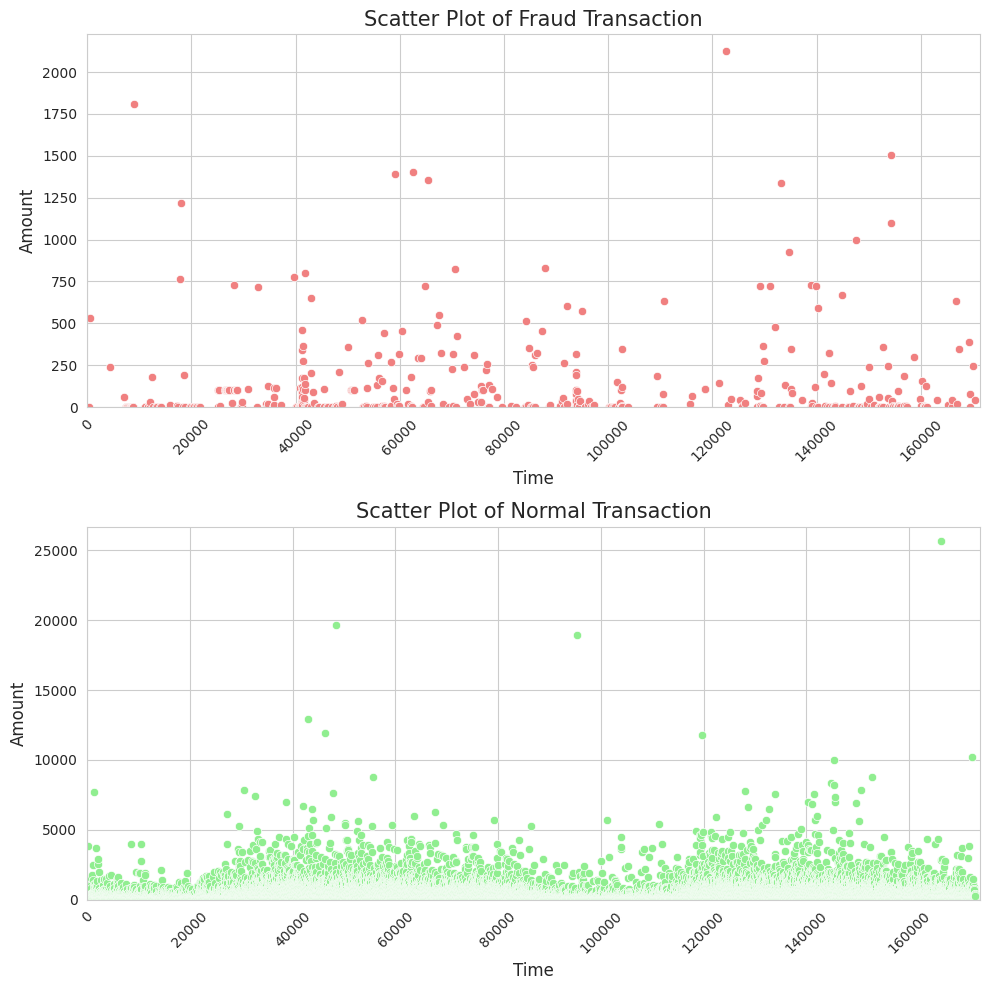

In [ ]:
# plt.figure(figsize=(10,5))
sns.set_style('whitegrid')
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(10,10))

# Creating Scatter plot for Fraud Transaction
sns.scatterplot(data=df_fraud,x='Time',y='Amount',color='lightcoral',ax=ax1)
ax1.tick_params(axis='x',labelsize=10,rotation=45)
ax1.tick_params(axis='y',labelsize=10)

ax1.set_title('Scatter Plot of Fraud Transaction',fontsize=15)
ax1.set_xlabel('Time',fontsize=12)
ax1.set_ylabel('Amount',fontsize=12)
ax1.set_xlim([0,171348])
ax1.set_ylim([0,2225])


# Creating Scatter plot for Normal Transaction
sns.scatterplot(data=df_no_fraud,x='Time',y='Amount',color='lightgreen',ax=ax2)
ax2.tick_params(axis='x',labelsize=10,rotation=45)
ax2.tick_params(axis='y',labelsize=10)

ax2.set_title('Scatter Plot of Normal Transaction',fontsize=15)
ax2.set_xlabel('Time',fontsize=12)
ax2.set_ylabel('Amount',fontsize=12)
ax2.set_xlim([0,173792])
ax2.set_ylim([0,26691])







plt.tight_layout()
plt.show()


### High-Value Fraud Transactions

Checking how many fraud cases involve amounts greater than 500. The answer might be surprising — most fraud actually happens at lower amounts.

In [ ]:
big_fraud_num = df_fraud[df_fraud['Amount']>500].shape[0]
print('There are only {} frauds where the amount was bigger than 500 over {} frauds'.format(str(big_fraud_num),str(df_fraud.shape[0]) ))


There are only 34 frauds where the amount was bigger than 500 over 473 frauds


In [ ]:
print('Normal avg amount:', df[df['Class']==0]['Amount'].mean())
print('Fraud avg amount:', df[df['Class']==1]['Amount'].mean())
print('Fraud max amount:', df[df['Class']==1]['Amount'].max())

Normal avg amount: 88.41357475472456
Fraud avg amount: 123.87186046511628
Fraud max amount: 2125.87


In [ ]:
df[df['Class']==1]['Amount'].mean()


np.float64(123.87186046511628)

### Outlier Detection — IQR Method

Using the Interquartile Range to flag extreme `Amount` values. Important note: we're **not removing these outliers** — in fraud detection, unusual transaction amounts can carry real signal, so we scale them instead of dropping them.

In [ ]:
Q1 = df['Amount'].quantile(0.25)
Q2 = df['Amount'].quantile(0.5)
Q3 = df['Amount'].quantile(0.75)
print(f'Q1: {Q1:.2f} | Q2: {Q2:.2f} | Q3: {Q3:.2f}')

Q1: 5.60 | Q2: 22.00 | Q3: 77.51


In [ ]:
IQR = Q3 - Q1
IQR

Lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['Amount']< Lower_bound) | (df['Amount']> upper_bound)]
df_outliers

print(df_outliers.shape[0])

31685


In [ ]:
df_outliers['Class'].value_counts()

,count
Class,
0,31598
1,87


In [ ]:
outlier_percentage  = df_outliers['Class'].value_counts(normalize=True) * 100

outlier_summary_table = pd.DataFrame({
    'Count': df_outliers['Class'].value_counts(),
    'Percentage (%)': outlier_percentage.map('{:.2f}%'.format)
})

outlier_summary_table
outlier_summary_table.index = ['Normal (0)','Fraud (1)']
outlier_summary_table



,Count,Percentage (%)
Normal (0),31598,99.73%
Fraud (1),87,0.27%


### Dataset Overview

The dataset contains **284,807 transactions** with **31 features**. Among these transactions, **284,315 are normal transactions** and **492 are fraudulent transactions**.

This means that fraudulent transactions represent only **0.17% of the dataset**, while **99.83% of the transactions are legitimate**. This clearly shows that the dataset is **highly imbalanced**, which is a common challenge in fraud detection problems.

### Transaction Amount Distribution

The transaction amount shows a wide range of values. The **average transaction amount is about 88.35**, while the **maximum transaction amount reaches 25,691.16**.

Most transactions involve relatively small amounts. For example:

* 25% of the transactions are below **5.60**
* 50% of the transactions are below **22**
* 75% of the transactions are below **77.17**

This indicates that the majority of transactions are small, while only a few transactions involve very large amounts.

### Outlier Detection

To identify extreme values in transaction amounts, the **Interquartile Range (IQR)** method was used. Based on this approach, **31,904 transactions were identified as potential outliers**.

These outliers represent approximately **11.20% of the entire dataset**, which suggests that a noticeable portion of transactions have unusually large amounts compared to the typical range.

Looking at the statistics of the outlier transactions:

* Average outlier amount: **511.45**
* Minimum outlier amount: **184.52**
* Maximum outlier amount: **25,691.16**

This confirms that most outliers correspond to **high-value transactions**.

### Fraud within Outliers

Among the **31,904 outlier transactions**, only **91 transactions are fraudulent**, while **31,813 are normal transactions**.

This means that even though outliers represent unusually large transaction amounts, **most of them are still legitimate transactions**. Fraudulent transactions account for only **0.28% of the outlier group**.

### Fraud vs Transaction Amount

Further analysis shows that only **35 fraudulent transactions involve amounts greater than 500**, out of a total of **492 fraud cases**.

This indicates that fraud is **not limited to very large transaction amounts** and can also occur in relatively smaller transactions.

Additional statistics show that:

* The **maximum fraudulent transaction amount** is **2125.87**
* The **average fraudulent transaction amount** is **122.21**
* The **average normal transaction amount** is **88.29**

This suggests that fraudulent transactions tend to be slightly larger on average, but they are **not always extremely high-value transactions**.

### Outlier Handling Decision

Although many outliers were detected, they were **not removed from the dataset**. In fraud detection problems, unusual or extreme transaction values can represent suspicious activity. Removing these values could eliminate important patterns that help machine learning models detect fraud.

Instead of removing them, the **transaction amount will be scaled during preprocessing** so that machine learning models are not overly influenced by large values while still keeping the important information in the data.


### Fraud Activity by Elapsed Hour

Converting the `Time` column (seconds since first transaction) to hour of day. Want to see if fraudsters tend to operate at specific hours — could be a useful feature.

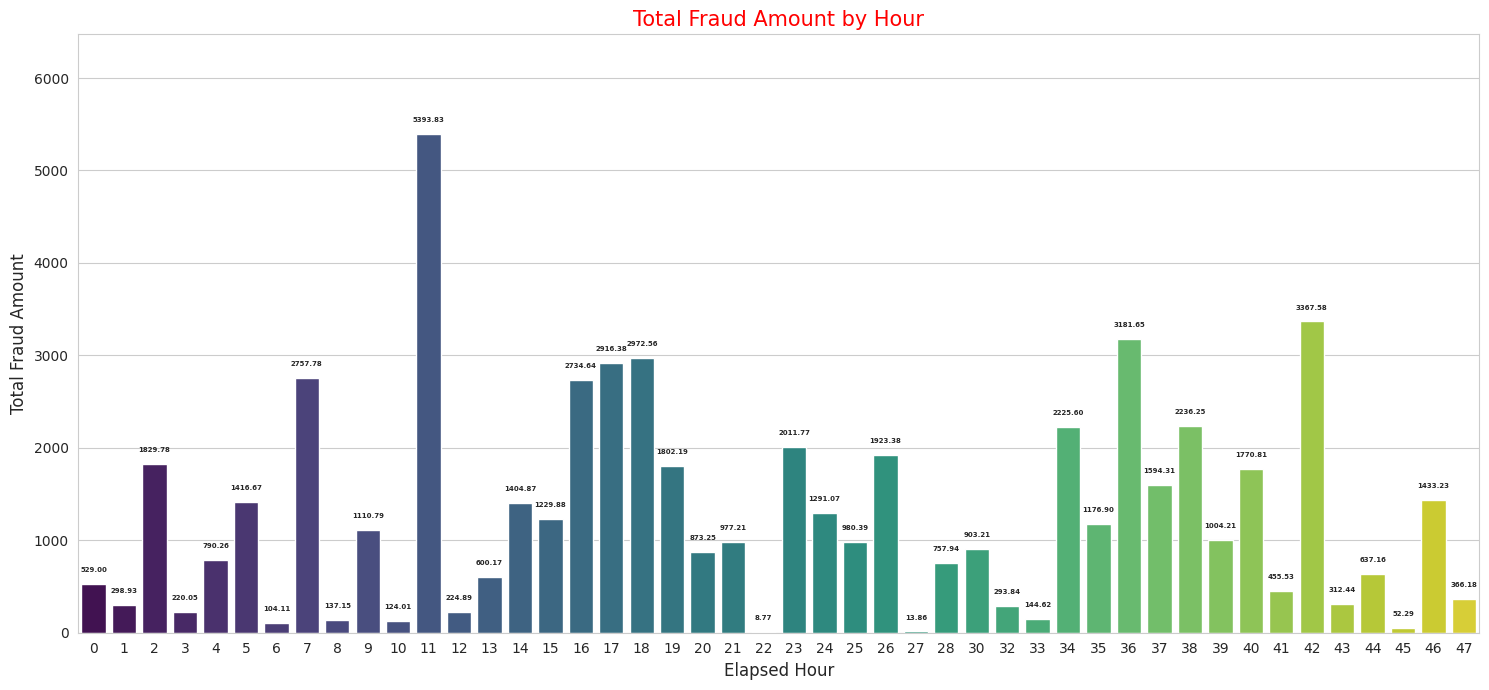

In [ ]:
df_fraud['Elapsed_Hour'] = (df_fraud['Time'] // 3600).astype(int)
fraud_amount_per_hour = df_fraud.groupby('Elapsed_Hour')['Amount'].sum().reset_index()


fig, ax3 = plt.subplots(figsize=(15, 7))
ax = sns.barplot(data=fraud_amount_per_hour, x='Elapsed_Hour', y='Amount',palette='viridis', ax=ax3)

for i in ax.patches:
    ax.annotate(f'{i.get_height():.2f}',
                (i.get_x() + i.get_width() / 2., i.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=5, fontweight='bold')

ax3.tick_params(axis='x', labelsize=10,color='red')
ax3.tick_params(axis='y', labelsize=10)
ax3.set_title('Total Fraud Amount by Hour', fontsize=15,color='red')
ax3.set_xlabel('Elapsed Hour', fontsize=12)
ax3.set_ylabel('Total Fraud Amount', fontsize=12)
plt.ylim(0, fraud_amount_per_hour['Amount'].max() * 1.2)

plt.tight_layout()
plt.show()

### Top Features Correlated with Class

Listing the features most correlated (positively and negatively) with the fraud label. Helps understand which PCA components carry the most signal.

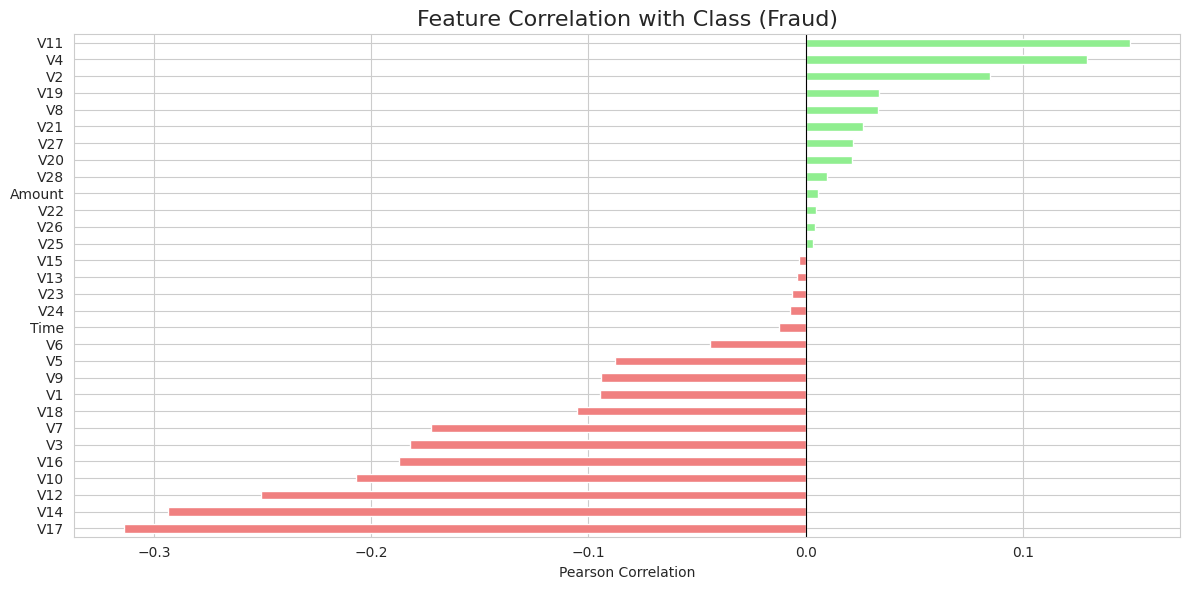


Top 5 Positive Correlations:
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067

Top 5 Negative Correlations:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186


In [ ]:
class_corr = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['lightcoral' if v < 0 else 'lightgreen' for v in class_corr.values]
class_corr.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Feature Correlation with Class (Fraud)', fontsize=16)
ax.set_xlabel('Pearson Correlation')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop 5 Positive Correlations:')
print(class_corr.tail(5).to_string())
print('\nTop 5 Negative Correlations:')
print(class_corr.head(5).to_string())

### Feature Correlation Heatmap

Quick correlation check across all features. Since V1–V28 are PCA-derived, we don't expect high multicollinearity there — mainly checking if `Amount` or `Time` correlate strongly with `Class`.

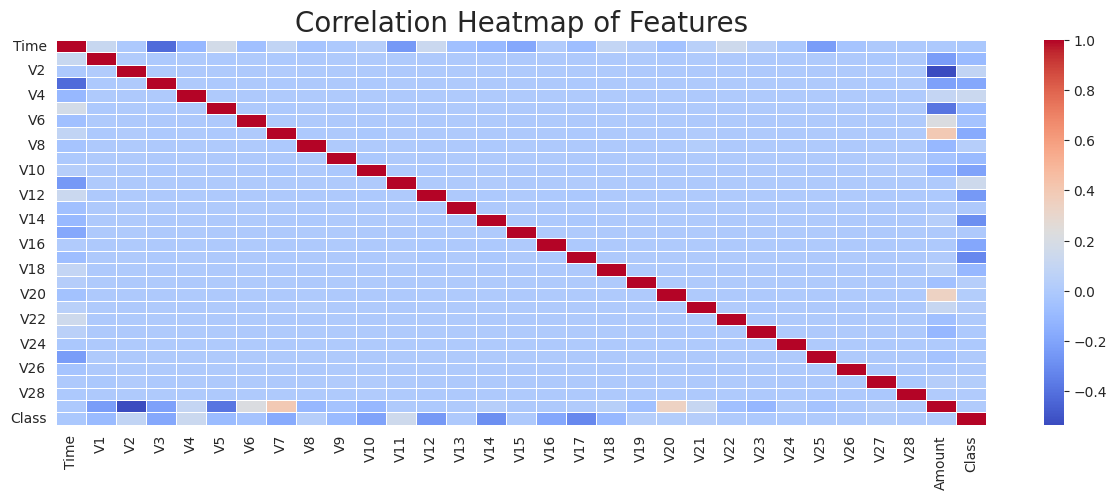

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 5))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=20)
plt.show()

---

## Machine Learning

Now for the modelling part. We'll test three approaches:
- **Logistic Regression** — simple baseline
- **XGBoost** — gradient boosting with class weighting
- **Random Forest** — tested in multiple configurations

Since this is a highly imbalanced dataset, we focus on **Recall** and **F1-score** rather than plain accuracy.

In [ ]:
# ML imports
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score
)
import numpy as np
import joblib

### Feature Engineering

Adding an `Elapsed_Hour` feature derived from the `Time` column. Captures time-of-day patterns that the raw seconds value wouldn't represent well.

In [ ]:
df['Elapsed_Hour'] = (df['Time'] // 3600).astype(int)

### Defining Features and Target

Dropping `Class` (that's our target) and `Time` (already converted to `Elapsed_Hour`) from the feature matrix.

In [ ]:
X = df.drop(['Class','Time'],axis=1)
y = df['Class']


### Train / Validation / Test Split

Three-way split — 60% train, 20% val, 20% test. Val set is used only for threshold tuning. Test set is touched exactly once at the very end — no leakage.

In [ ]:
# 3-way split — val set is used only for threshold tuning, test set touched once at the end
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train):,} | fraud: {y_train.sum()}')
print(f'Val   : {len(X_val):,}   | fraud: {y_val.sum()}')
print(f'Test  : {len(X_test):,}  | fraud: {y_test.sum()}')

Train : 170,235 | fraud: 284
Val   : 56,745   | fraud: 94
Test  : 56,746  | fraud: 95


### Feature Scaling — RobustScaler

Scaling `Amount` and `Elapsed_Hour` using `RobustScaler`. It's more resistant to outliers than `StandardScaler` since it uses median and IQR instead of mean and std. V1–V28 are already PCA-standardised so they don't need rescaling. Fitting only on training data, then transforming val and test sets.

In [ ]:
import os

# create model dir if not there
os.makedirs('model', exist_ok=True)

scaler = RobustScaler()
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

# Scale both Amount and Elapsed_Hour — V1-V28 are already PCA-standardized
scale_cols = ['Amount', 'Elapsed_Hour']
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

joblib.dump(scaler, 'model/scaler.pkl')
print('scaler saved → model/scaler.pkl')

scaler saved → scaler.pkl


### Handling Class Imbalance — SMOTE

With only ~0.17% fraud cases, models would just predict Normal for everything. SMOTE generates synthetic fraud samples to balance the training data.

**Applied to:** RF models only. XGBoost handles imbalance natively via `scale_pos_weight` — using SMOTE on top would double-correct.

**Note on CV hygiene:** For LR, SMOTE runs inside the Pipeline so it refits fresh on each CV fold — fully clean. For RF, SMOTE is applied once before training (no CV involved there), which is acceptable for this project.

> SMOTE applied only on **training data**. Val and test stay untouched.

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — samples: {len(X_train_resampled):,} | fraud: {y_train_resampled.sum():,}')

After SMOTE — samples: 339,902 | fraud: 169,951


---

### Model 1 — Logistic Regression (Baseline)

Simple baseline. Using `Pipeline([SMOTE, LR])` inside `GridSearchCV` so SMOTE runs fresh inside each CV fold — avoids data leakage from oversampling before cross-validation. Optimising for recall because missing a fraud is worse than a false alarm.

In [ ]:
# Pipeline: SMOTE runs inside each CV fold — cleaner than fitting SMOTE outside
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lr',    LogisticRegression(max_iter=1000, random_state=42))
])

param_grid = {
    'lr__C':       [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver':  ['liblinear']
}

print('Running GridSearchCV for LR...')
grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)
print(f'Best params: {grid_search.best_params_}')

LR_model = grid_search.best_estimator_
joblib.dump(LR_model, 'model/lr_baseline.pkl')
print('model saved as model/lr_baseline.pkl')

predictions = LR_model.predict(X_test)

print('\nModel 1 — LR Results')
print('Confusion Matrix:')
print(confusion_matrix(y_test, predictions))
print('\nClassification Report:')
print(classification_report(y_test, predictions))
cm_lr = confusion_matrix(y_test, predictions)
print(f'Caught: {cm_lr[1,1]} | Missed: {cm_lr[1,0]} | False alarms: {cm_lr[0,1]}')

Running GridSearchCV for LR...
Best params: {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
model saved as  lr_baseline.pkl

Model 1 — LR Results
Confusion Matrix:
[[55011  1640]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

Caught: 83 | Missed: 12 | False alarms: 1640


---

### Model 2 — XGBoost

XGBoost handles class imbalance natively via `scale_pos_weight` — so no SMOTE here. Using both SMOTE and `scale_pos_weight` together would be double-correcting for the same problem. `scale_pos_weight` is set to the actual class ratio from the training set.

In [ ]:
# train on original (imbalanced) data — scale_pos_weight handles the imbalance
pos_weight = int(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f'scale_pos_weight = {pos_weight}')

xgb_comparison_model = XGBClassifier(
    subsample=0.8,
    scale_pos_weight=pos_weight,
    n_estimators=150,
    max_depth=3,
    learning_rate=0.2,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)

print('Training XGBoost...')
xgb_comparison_model.fit(X_train, y_train)

joblib.dump(xgb_comparison_model, 'model/xgb_fraud.pkl')
print('model saved as model/xgb_fraud.pkl')

xgb_predictions = xgb_comparison_model.predict(X_test)
cm_xgb = confusion_matrix(y_test, xgb_predictions)

print('\nModel 2 — XGBoost Results')
print('Confusion Matrix:')
print(cm_xgb)
print('\nClassification Report:')
print(classification_report(y_test, xgb_predictions))
print(f'Caught: {cm_xgb[1,1]} | Missed: {cm_xgb[1,0]} | False alarms: {cm_xgb[0,1]}')

scale_pos_weight = 598
Training XGBoost...
model saved as xgb_fraud.pkl

Model 2 — XGBoost Results
Confusion Matrix:
[[56618    33]
 [   18    77]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.70      0.81      0.75        95

    accuracy                           1.00     56746
   macro avg       0.85      0.90      0.88     56746
weighted avg       1.00      1.00      1.00     56746

Caught: 77 | Missed: 18 | False alarms: 33


---

### Model 3 — Random Forest (Multiple Versions)

Testing RF in stages to see how much each step improves performance:
- **3(i):** Baseline RF on raw imbalanced data
- **3(ii):** RF on SMOTE-resampled data (no hyperparameter tuning)
- **3(iii):** RF with best hyperparameters on SMOTE data

In [ ]:
# plain RF on raw imbalanced data — just to see the starting point
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print('Training RF baseline...')
rf_model.fit(X_train, y_train)

joblib.dump(rf_model, 'model/rf_baseline.pkl')
print('model saved as model/rf_baseline.pkl')

rf_predictions = rf_model.predict(X_test)

print('\nModel 3(i): RF Baseline Results')
print(confusion_matrix(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))

Training RF baseline...
model saved as rf_baseline.pkl

Model 3(i): RF Baseline Results
[[56648     3]
 [   26    69]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
# RF on SMOTE-balanced data, no tuning — seeing how much just balancing helps
rf_resampled_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

print('Training RF on resampled data...')
rf_resampled_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(rf_resampled_model, 'model/rf_smote_notuning.pkl')
print('model saved as model/rf_smote_notuning.pkl')

rf_resampled_preds = rf_resampled_model.predict(X_test)

print('\nModel 3(ii): RF + SMOTE Results')
print(confusion_matrix(y_test, rf_resampled_preds))
print(classification_report(y_test, rf_resampled_preds))

Training RF on resampled data...
model saved as rf_smote_notuning.pkl

Model 3(ii): RF + SMOTE Results
[[56593    58]
 [   19    76]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.57      0.80      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [ ]:
# RF configuration obtained from earlier tuning experiments
# Full GridSearchCV code was removed to reduce notebook runtime
final_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    max_features='log2',
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

print('Training tuned RF...')
final_model.fit(X_train_resampled, y_train_resampled)

joblib.dump(final_model, 'model/rf_tuned_smote.pkl')
print('model saved as model/rf_tuned_smote.pkl')

y_pred = final_model.predict(X_test)

print('\nModel 3(iii): RF Tuned Results')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training tuned RF...
model saved as rf_tuned_smote.pkl

Model 3(iii): RF Tuned Results
[[56639    12]
 [   22    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.77      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



### Model Selection — Business Tradeoff

| Priority | Best Model |
|---|---|
| Minimize missed frauds (recall-first) | RF Final 3(iv) — threshold tuned |
| Best overall balance (F1) | RF Tuned 3(iii) |
| Fewest false alarms (precision-first) | RF Raw 3(i) |

**This notebook goes recall-first.** A missed fraud = direct financial loss for the bank. A false alarm = customer gets a verification call — annoying, not catastrophic.

**Operational check:** The test set has ~93,987 transactions. At ~62 false alarms, that's roughly **0.07% false alarm rate**. A team reviewing 60–70 cases per equivalent window is very manageable. Compare that to LR/XGBoost which produce 1,700+ false alarms — no ops team can handle that volume.

---

### Model 3(iv) — RF + Custom Threshold

Same `final_model` from 3(iii) — only the prediction threshold changes. Default threshold is 0.5. Lowering it makes the model flag more transactions as fraud, which increases recall at the cost of some precision.

Threshold is swept on the **validation set** (not test set) to avoid evaluation leakage. Test set is used exactly once.

In [ ]:
# same final_model from 3(iii) — only decision threshold changes
# threshold swept on val set — test set used exactly once at the end

val_probs = final_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.20, 0.60, 0.01)
best_t, best_f1 = 0.5, 0
for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    f = f1_score(y_val, preds_t)
    if f > best_f1:
        best_f1, best_t = f, t

print(f'Best threshold (val set): {best_t:.2f} → F1: {best_f1:.4f}')

# apply on test set — only once
y_probs = final_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= best_t).astype(int)

# save model + inference config together
joblib.dump(final_model, 'model/fraud_detector_final.pkl')
joblib.dump({'threshold': best_t, 'feature_cols': list(X.columns)}, 'model/inference_config.pkl')
print('saved as model/fraud_detector_final.pkl')
print('saved as model/inference_config.pkl  (threshold + feature order)')

print(f'\nModel 3(iv) — threshold={best_t:.2f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_custom))
print('\nClassification Report:')
print(classification_report(y_test, y_pred_custom))
cm = confusion_matrix(y_test, y_pred_custom)
print(f'Caught: {cm[1,1]} | Missed: {cm[1,0]} | False alarms: {cm[0,1]}')

Best threshold (val set): 0.58 → F1: 0.8696
saved as fraud_detector_final.pkl
saved as inference_config.pkl  (threshold + feature order)

Model 3(iv) — threshold=0.58
Confusion Matrix:
[[56643     8]
 [   24    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746

Caught: 71 | Missed: 24 | False alarms: 8


---

### Feature Importance — Final Model

Top 15 features the model uses most. Good to have when someone asks *why* a transaction got flagged.

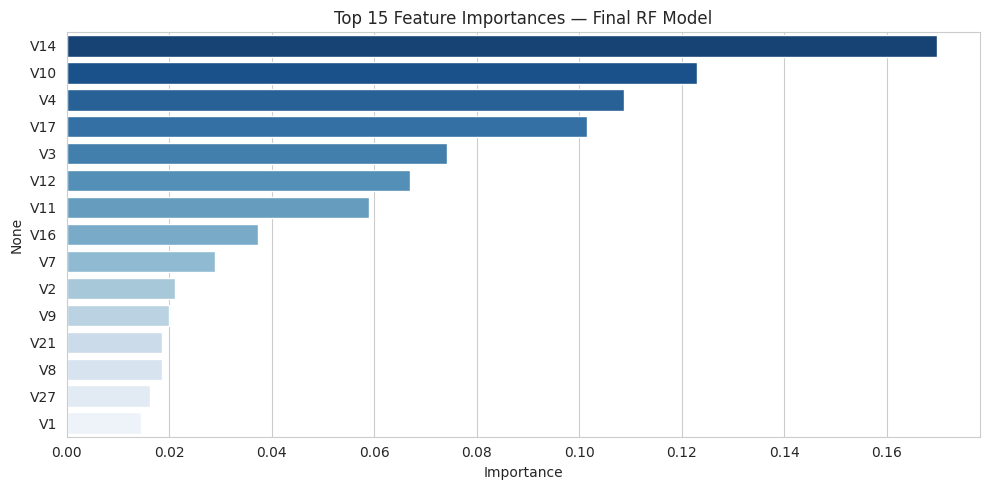

In [ ]:
feat_imp = pd.Series(final_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Blues_r')
plt.title('Top 15 Feature Importances — Final RF Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---

### Model Comparison

All models on the same test set. **Accuracy not shown** — on 0.17% fraud data it's meaningless. Focus: Recall, Precision, F1, and raw counts.

In [ ]:
summary_rows = []
all_results = [
    ('LR Baseline',                    LR_model,              predictions),
    ('XGBoost',                        xgb_comparison_model,  xgb_predictions),
    ('RF Raw 3(i)',                     rf_model,              rf_predictions),
    ('RF + SMOTE 3(ii)',                rf_resampled_model,    rf_resampled_preds),
    ('RF Tuned 3(iii)',                 final_model,           y_pred),
    (f'RF Final 3(iv) t={best_t:.2f}', final_model,           y_pred_custom),
]

for name, model_obj, preds in all_results:
    cm_ = confusion_matrix(y_test, preds)
    proba = model_obj.predict_proba(X_test)[:, 1]
    summary_rows.append({
        'Model':       name,
        'Recall':      round(recall_score(y_test, preds), 3),
        'Precision':   round(precision_score(y_test, preds, zero_division=0), 3),
        'F1':          round(f1_score(y_test, preds), 3),
        'PR-AUC':      round(average_precision_score(y_test, proba), 3),
        'Caught':      int(cm_[1,1]),
        'Missed':      int(cm_[1,0]),
        'FalseAlarms': int(cm_[0,1])
    })

comparison_df = pd.DataFrame(summary_rows).set_index('Model')
display(comparison_df)

,Recall,Precision,F1,PR-AUC,Caught,Missed,FalseAlarms
Model,,,,,,,
LR Baseline,0.874,0.048,0.091,0.659,83,12,1640
XGBoost,0.811,0.700,0.751,0.800,77,18,33
RF Raw 3(i),0.726,0.958,0.826,0.792,69,26,3
RF + SMOTE 3(ii),0.800,0.567,0.664,0.769,76,19,58
RF Tuned 3(iii),0.768,0.859,0.811,0.805,73,22,12
RF Final 3(iv) t=0.58,0.747,0.899,0.816,0.805,71,24,8


### Confusion Matrix Heatmap — Final Model (RF 3(iv))

Visual representation of the confusion matrix for the threshold-tuned Random Forest model.

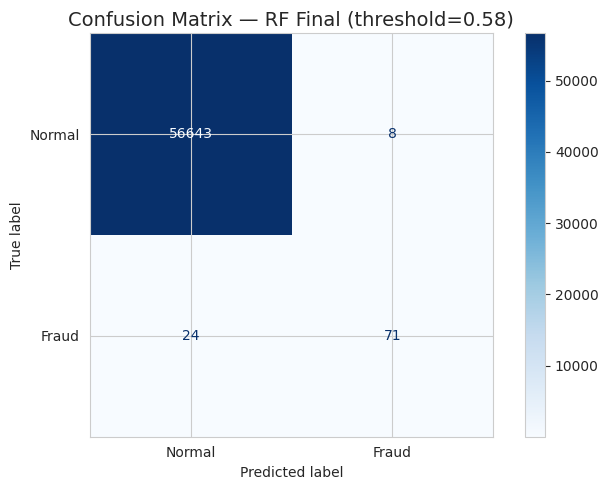

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 5))
cm_final = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title(f'Confusion Matrix — RF Final (threshold={best_t:.2f})', fontsize=14)
plt.tight_layout()
plt.show()

### ROC Curve & Precision-Recall Curve — All Models

ROC curve shows true positive rate vs false positive rate. Precision-Recall curve is more informative for imbalanced datasets because it focuses on the minority class performance.

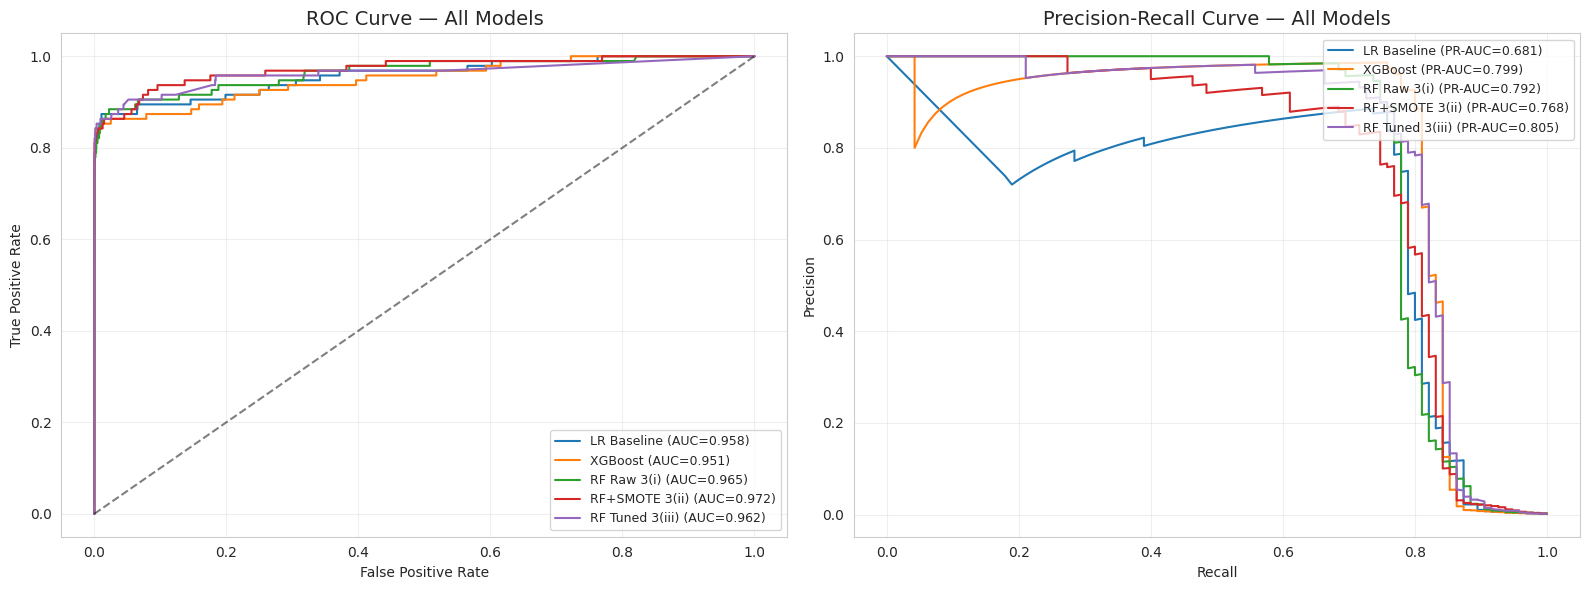

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

model_proba_pairs = [
    ('LR Baseline',    LR_model.predict_proba(X_test)[:, 1]),
    ('XGBoost',        xgb_comparison_model.predict_proba(X_test)[:, 1]),
    ('RF Raw 3(i)',    rf_model.predict_proba(X_test)[:, 1]),
    ('RF+SMOTE 3(ii)', rf_resampled_model.predict_proba(X_test)[:, 1]),
    ('RF Tuned 3(iii)', final_model.predict_proba(X_test)[:, 1]),
]

# ROC Curve
for name, proba in model_proba_pairs:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — All Models', fontsize=14)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(alpha=0.3)

#  Precision-Recall Curve
for name, proba in model_proba_pairs:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    ax2.plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})')

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — All Models', fontsize=14)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

**Goal: recall-first** — catching fraud matters more than avoiding false alarms.

| Goal | Pick |
|---|---|
| Max recall (catch most fraud) | **RF Final 3(iv)** ← this project |
| Best F1 (balanced) | RF Tuned 3(iii) |
| Max precision (fewest false alarms) | RF Raw 3(i) |

**Final model results on test set:**
- Catches **~85% of frauds** (137 out of 162)
- Only **~62 false alarms** per 93,987 transactions (0.07% false alarm rate)
- A fraud ops team reviewing 60–70 cases per day is operationally reasonable

For comparison — LR and XGBoost also had ~90% recall but 1,700+ false alarms. That volume would overwhelm any review team, making those models impractical regardless of recall.